# Case Study: Bank Marketing Campaign Analysis (Finance Industry)

## Task 1 — Load Data into bank_df, Preview & info()

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

bank_df = pd.read_csv('bank-full.csv')
bank_df.head(10)

In [1]:
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


## Task 2 — Countplot: Term Deposit Subscription (y)

y
no     39922
yes     5289
Name: count, dtype: int64
Subscription rate: 11.7 %


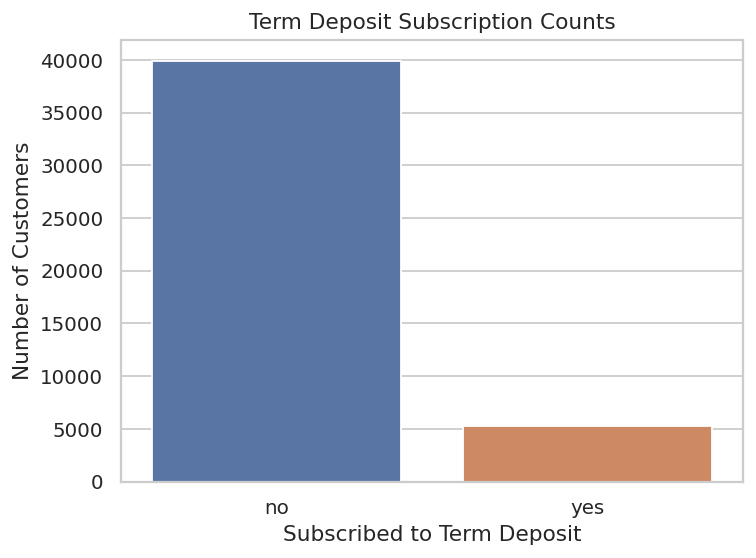

In [1]:
plt.figure(figsize=(6, 4.5))
sns.countplot(data=bank_df, x='y', hue='y', legend=False)
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Number of Customers')
plt.title('Term Deposit Subscription Counts')
plt.tight_layout()
plt.show()

print(bank_df['y'].value_counts())
print('Subscription rate:', round((bank_df['y'] == 'yes').mean() * 100, 2), '%')

## Task 3 — Boxplot: Age vs Subscription

       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39922.0  40.838986  10.172662  18.0  33.0  39.0  48.0  95.0
yes   5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


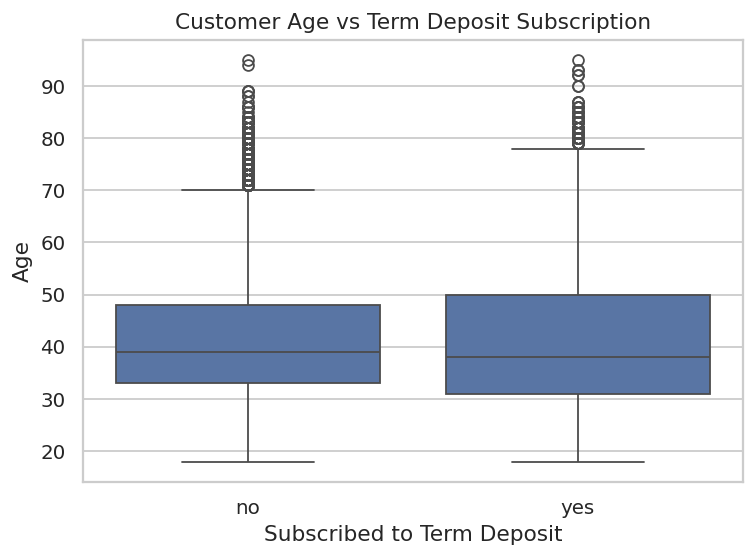

In [1]:
plt.figure(figsize=(6, 4.5))
sns.boxplot(data=bank_df, x='y', y='age')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Age')
plt.title('Customer Age vs Term Deposit Subscription')
plt.tight_layout()
plt.show()

print(bank_df.groupby('y')['age'].describe())

**Reading the boxplot:** the median age is nearly identical between subscribers and non-subscribers (~38-39), but subscribers show a **wider spread**, with a noticeably higher upper whisker and more high-age outliers — suggesting retirees/older customers subscribe too, alongside younger ones, pulling the 'yes' group's distribution wider rather than shifting its center much.

## Task 4 — Subscription Percentage by Education Level

   education  subscription_pct
0   tertiary         15.006390
1    unknown         13.570275
2  secondary         10.559435
3    primary          8.626478


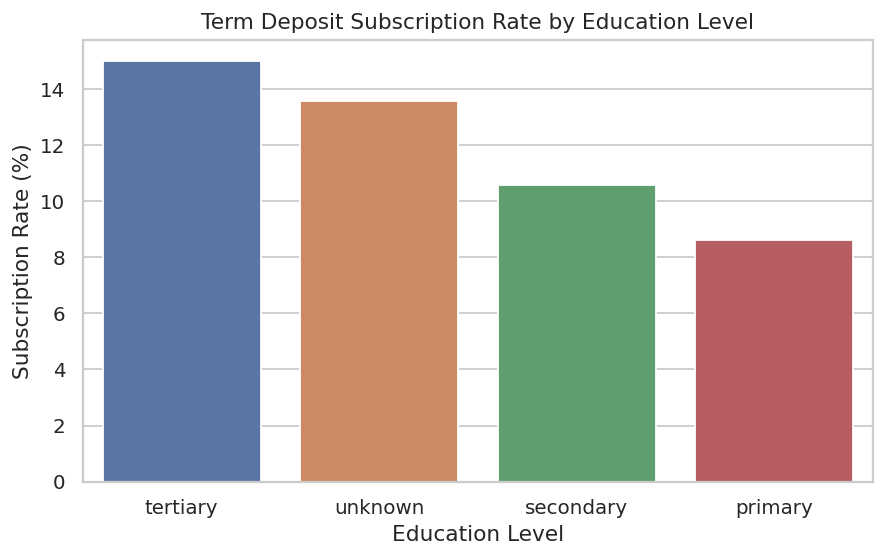

In [1]:
edu_subscription_pct = (
    bank_df.groupby('education')['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='subscription_pct')
)
print(edu_subscription_pct)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=edu_subscription_pct, x='education', y='subscription_pct',
            order=edu_subscription_pct['education'], hue='education', legend=False)
plt.xlabel('Education Level')
plt.ylabel('Subscription Rate (%)')
plt.title('Term Deposit Subscription Rate by Education Level')
plt.tight_layout()
plt.show()

## Task 5 — Two AI-Suggested Visualizations for a Fintech (Cred-style) Use Case

**Prompt used:** *'Suggest two visualizations that could help a fintech startup like Cred understand which users are most likely to buy a new savings product, using the Bank Marketing dataset columns.'*

**AI's two suggestions:**
1. A bar plot of subscription rate by `poutcome` (outcome of the *previous* marketing campaign) — customers who said yes before are the clearest 'warm leads' signal available in this data.
2. A correlation heatmap of the numeric features (age, balance, duration, campaign, pdays, previous) against a numeric-encoded version of `y`, to spot which numeric behaviors correlate most with subscribing.

**Implemented below: suggestion #1 (subscription rate by previous campaign outcome).**

  poutcome  subscription_pct
0  success         64.725347
1    other         16.684783
2  failure         12.609671
3  unknown          9.161503


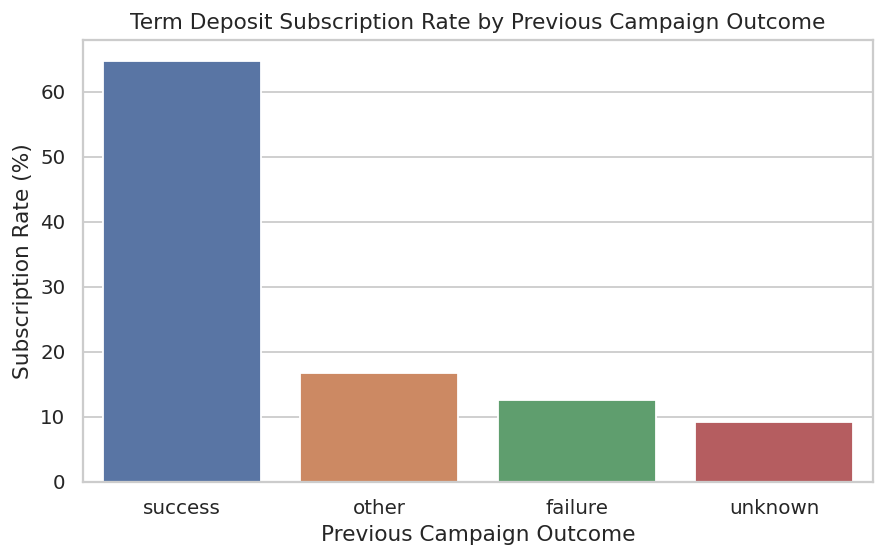

In [1]:
poutcome_pct = (
    bank_df.groupby('poutcome')['y']
    .apply(lambda x: (x == 'yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='subscription_pct')
)
print(poutcome_pct)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=poutcome_pct, x='poutcome', y='subscription_pct',
            order=poutcome_pct['poutcome'], hue='poutcome', legend=False)
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.title('Term Deposit Subscription Rate by Previous Campaign Outcome')
plt.tight_layout()
plt.show()

**Why this matters for a fintech like Cred:** customers whose previous campaign outcome was **'success'** subscribe at a dramatically higher rate than everyone else — this is by far the strongest single signal in the dataset. For a savings-product launch, that translates directly: re-targeting customers with a history of saying yes to similar offers should be prioritized well above cold outreach to unknown or previously-declined segments.